In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Load the MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape : (10000, 28, 28)


Train shape after reshape: (60000, 28, 28, 1)


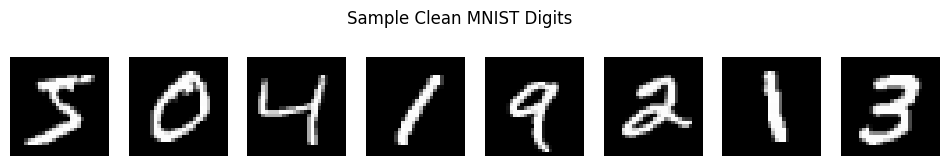

In [3]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Train shape after reshape:", x_train.shape)
n = 8
plt.figure(figsize=(12, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Sample Clean MNIST Digits")
plt.show()

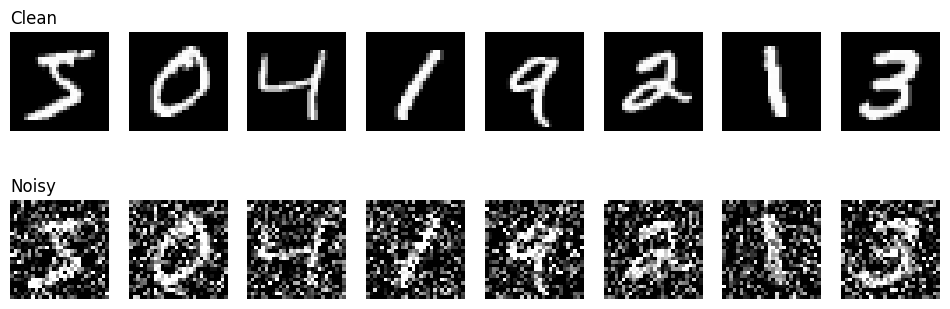

In [4]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

n = 8
plt.figure(figsize=(12, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Clean", loc='left')

    ax = plt.subplot(2, n, n + i + 1)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Noisy", loc='left')
plt.show()

In [5]:
def build_denoising_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1))


    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)


    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    return models.Model(input_img, decoded, name="denoising_autoencoder")

autoencoder = build_denoising_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy, x_train,        # input = noisy, target = clean
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.1585 - val_loss: 0.1150
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1123 - val_loss: 0.1080
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1073 - val_loss: 0.1045
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1044 - val_loss: 0.1027
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1026 - val_loss: 0.1010
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1014 - val_loss: 0.1001
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1003 - val_loss: 0.0989
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0995 - val_loss: 0.0982
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0988 - val_loss: 0.0976
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0982 - val_loss: 0.0971


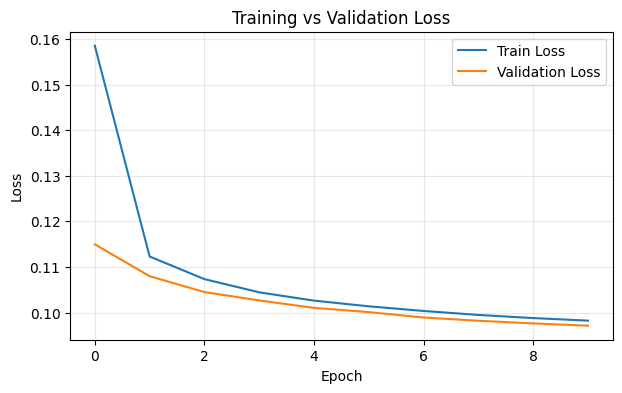

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [8]:
denoised_images = autoencoder.predict(x_test_noisy)
print("Denoised output shape:", denoised_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Denoised output shape: (10000, 28, 28, 1)


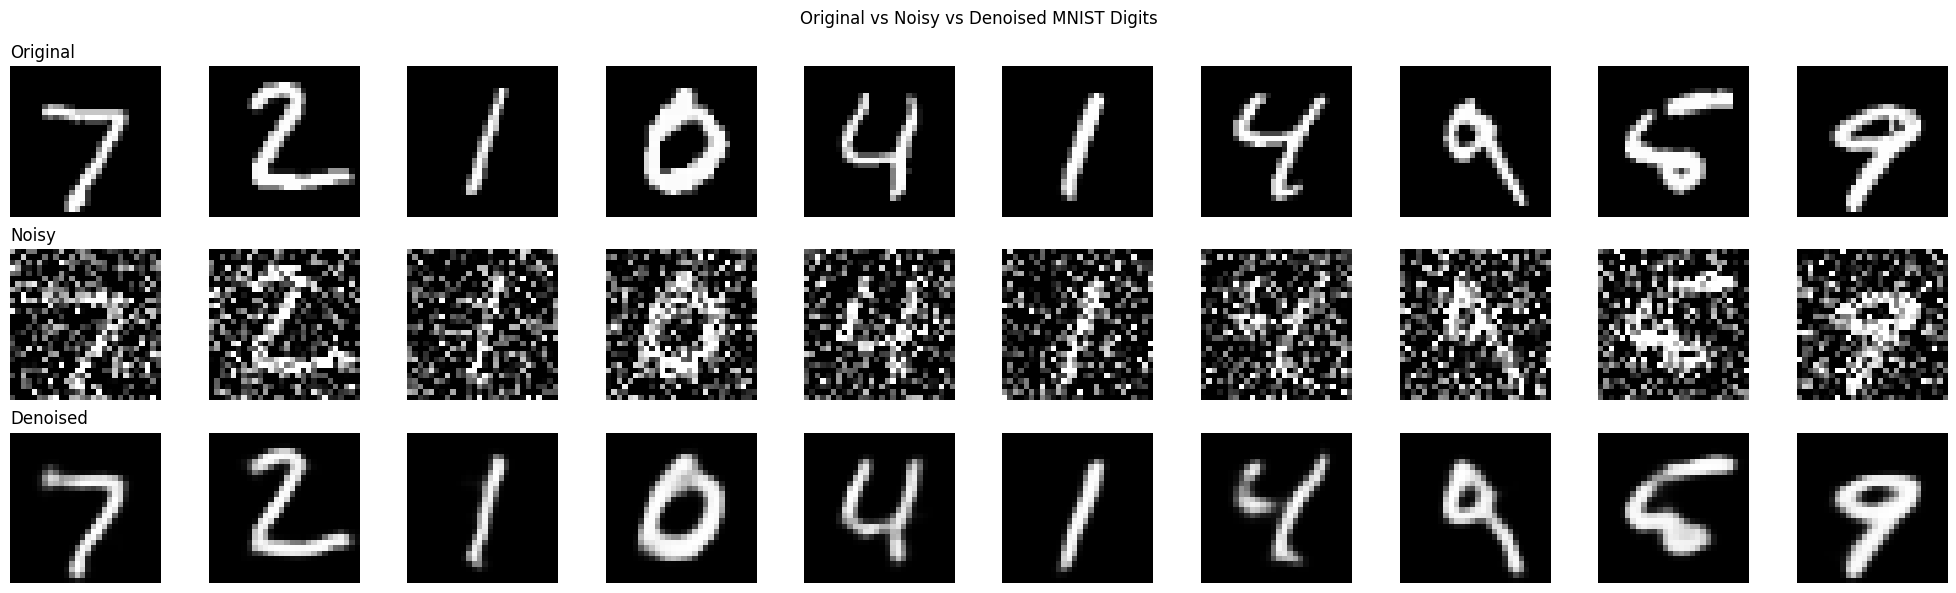

In [9]:
# visualize results(Original vs Noisy vs Denoised)
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: ax.set_title("Original", loc='left')

    ax = plt.subplot(3, n, n + i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: ax.set_title("Noisy", loc='left')

    ax = plt.subplot(3, n, 2*n + i + 1)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray'); plt.axis('off')
    if i == 0: ax.set_title("Denoised", loc='left')

plt.suptitle("Original vs Noisy vs Denoised MNIST Digits")
plt.tight_layout()
plt.show()

In [10]:

def mse(a, b):
    return np.mean(np.square(a - b))

def psnr(a, b, max_pixel=1.0):
    mse_val = mse(a, b)
    if mse_val == 0:
        return float('inf')
    return 20 * np.log10(max_pixel / np.sqrt(mse_val))

mse_noisy = mse(x_test, x_test_noisy)
mse_denoised = mse(x_test, denoised_images)
psnr_noisy = psnr(x_test, x_test_noisy)
psnr_denoised = psnr(x_test, denoised_images)

print(f"{'Metric':<12}{'Noisy':>12}{'Denoised':>12}")
print(f"{'MSE':<12}{mse_noisy:>12.5f}{mse_denoised:>12.5f}")
print(f"{'PSNR (dB)':<12}{psnr_noisy:>12.2f}{psnr_denoised:>12.2f}")

Metric             Noisy    Denoised
MSE              0.11548     0.01139
PSNR (dB)           9.37       19.43


In [11]:
from skimage.metrics import structural_similarity as ssim

ssim_scores = []

for i in range(len(x_test)):
    score = ssim(
        x_test[i].squeeze(),
        denoised_images[i].squeeze(),
        data_range=1.0
    )
    ssim_scores.append(score)

print("Average SSIM:", np.mean(ssim_scores))

Average SSIM: 0.863946236474772


In [12]:
# Calculate PSNR for Every Image
psnr_scores = []

for i in range(len(x_test)):
    mse = np.mean((x_test[i] - denoised_images[i])**2)

    if mse == 0:
        psnr = 100
    else:
        psnr = 20 * np.log10(1.0 / np.sqrt(mse))

    psnr_scores.append(psnr)

print("Average PSNR:", np.mean(psnr_scores))

Average PSNR: 19.77441


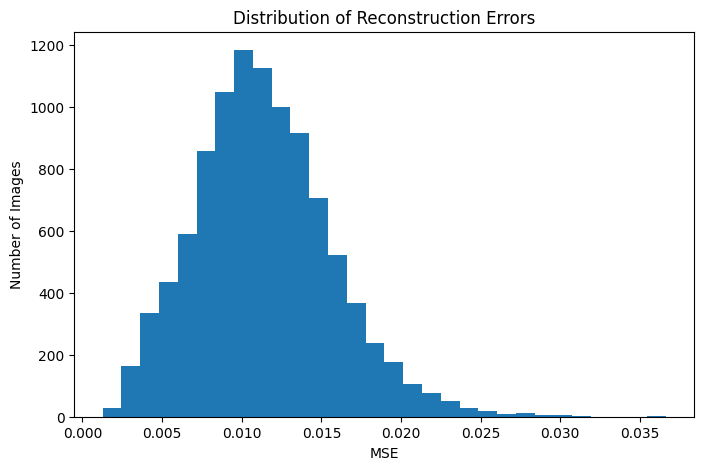

In [13]:
# Plot Histogram of Reconstruction Error
errors = np.mean((x_test - denoised_images)**2, axis=(1,2,3))

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)
plt.title("Distribution of Reconstruction Errors")
plt.xlabel("MSE")
plt.ylabel("Number of Images")
plt.show()

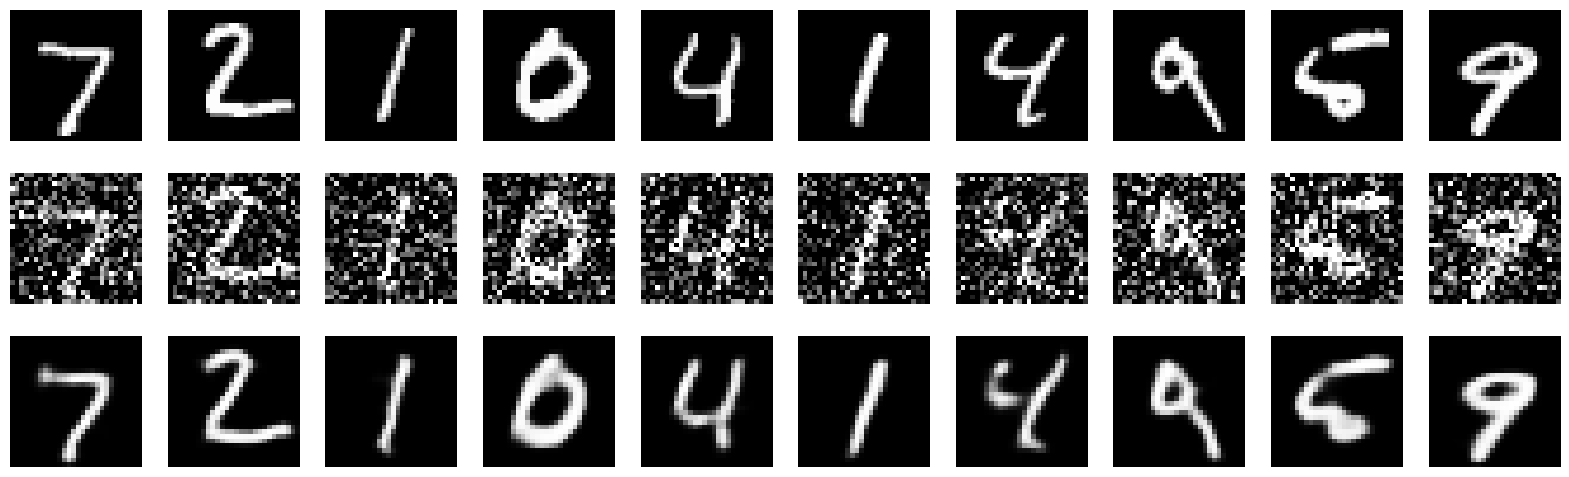

In [14]:
# Display More Test Results
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis("off")
    if i==0:
        plt.ylabel("Original")

    plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis("off")
    if i==0:
        plt.ylabel("Noisy")

    plt.subplot(3,n,i+2*n+1)
    plt.imshow(denoised_images[i].reshape(28,28), cmap='gray')
    plt.axis("off")
    if i==0:
        plt.ylabel("Denoised")

plt.show()

In [15]:
# Save the Trained Model
autoencoder.save("mnist_denoising_autoencoder.keras")

print("Model saved successfully.")

Model saved successfully.


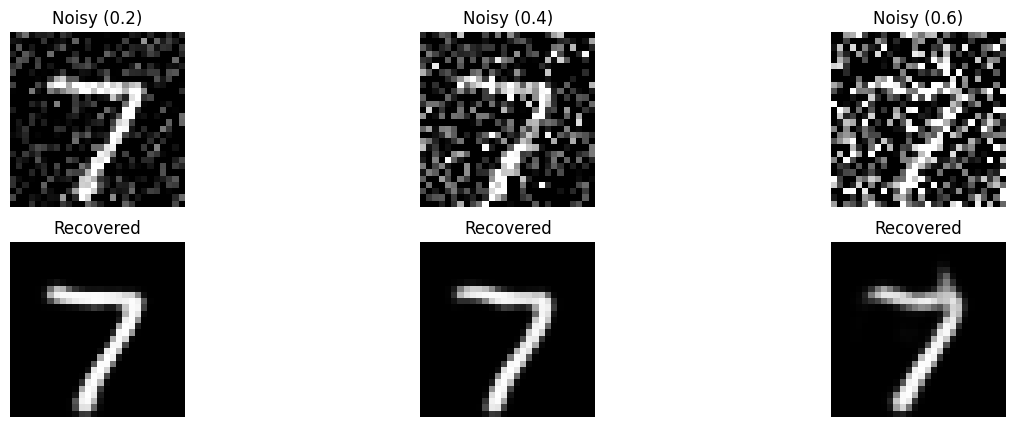

In [16]:
# Compare Different Noise Levels
noise_levels = [0.2, 0.4, 0.6]

plt.figure(figsize=(15,5))

for i, noise in enumerate(noise_levels):

    noisy = x_test[:1] + noise * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=x_test[:1].shape
    )

    noisy = np.clip(noisy, 0., 1.)

    denoised = autoencoder.predict(noisy, verbose=0)

    plt.subplot(2,3,i+1)
    plt.imshow(noisy.reshape(28,28), cmap='gray')
    plt.title(f"Noisy ({noise})")
    plt.axis("off")

    plt.subplot(2,3,i+4)
    plt.imshow(denoised.reshape(28,28), cmap='gray')
    plt.title("Recovered")
    plt.axis("off")

plt.show()

In [17]:
# Final Performance Table
import pandas as pd

results = {
    "Metric": [
        "Average MSE",
        "Average PSNR",
        "Average SSIM"
    ],
    "Value": [
        np.mean((x_test - denoised_images)**2),
        np.mean(psnr_scores),
        np.mean(ssim_scores)
    ]
}

df = pd.DataFrame(results)

print(df)

         Metric      Value
0   Average MSE   0.011393
1  Average PSNR  19.774410
2  Average SSIM   0.863946


# Autoencoder for Image Denoising using MNIST

## Project Objective

  The objective of this project is to develop a Convolutional Denoising Autoencoder capable of reconstructing clean handwritten digit images from noisy inputs. The model is trained on the MNIST dataset and evaluated using both visual comparisons and quantitative image quality metrics to assess its denoising performance.

## Data Preparation

  The MNIST handwritten digit dataset was loaded using the Keras dataset library, consisting of 60,000 training images and 10,000 testing images. Each grayscale image was normalized by scaling pixel values from the range **[0, 255]** to **[0, 1]**, which improves training stability and helps the neural network converge more efficiently. The images were then reshaped to **(28, 28, 1)** to make them compatible with convolutional neural network layers.

  To create a realistic denoising task, Gaussian noise with a noise factor of **0.5** was added to both the training and testing datasets. After adding noise, pixel values were clipped to remain within the valid range of **[0, 1]**. Visualizing the noisy images confirmed that the handwritten digits remained recognizable while containing significant random noise, providing an appropriate challenge for the autoencoder.

## Model Architecture

  A Convolutional Denoising Autoencoder was designed to learn compact image representations and reconstruct clean images from noisy inputs. The architecture consists of two major components: an encoder and a decoder.

### Encoder

  The encoder extracts meaningful features while reducing the spatial dimensions of the input image. It consists of:

* Two Conv2D layers with ReLU activation.
* Two MaxPooling2D layers for downsampling.
* A compact latent representation that captures the essential structural features of the handwritten digit.

### Decoder

  The decoder reconstructs the original image from the compressed representation. It consists of:

* Two Conv2D layers with ReLU activation.
* Two UpSampling2D layers to restore the original image dimensions.
* A final Conv2D layer with Sigmoid activation that generates the reconstructed image with pixel values between **0** and **1**.

  The bottleneck representation encourages the network to preserve important digit features while filtering out random noise.

## Model Summary

  The proposed autoencoder contains a relatively small number of trainable parameters, making it computationally efficient while maintaining strong reconstruction performance. The complete model architecture and parameter count can be verified using `autoencoder.summary()`.

## Training Configuration

  The model was trained using the following configuration:

* **Optimizer:** Adam
* **Loss Function:** Binary Cross-Entropy
* **Batch Size:** 128
* **Epochs:** 10
* **Early Stopping:** Patience = 5

  During training, noisy images were provided as inputs while the corresponding clean images served as target outputs. Both training and validation losses decreased consistently, indicating effective learning and good generalization.

## Training Performance

  The learning curves showed smooth and stable convergence throughout training.

### Observations

* Training loss decreased steadily across epochs.
* Validation loss closely followed the training loss.
* No significant signs of overfitting were observed.
* Early Stopping monitored validation loss and restored the best-performing model whenever necessary.

These observations indicate that the autoencoder successfully learned the mapping between noisy and clean images.

## Denoising Results

  The trained model effectively reconstructed clean handwritten digits from noisy inputs. A visual comparison of the **original**, **noisy**, and **reconstructed** images demonstrates the network's ability to remove a substantial amount of Gaussian noise while preserving the overall shape and identity of each digit.

  Most reconstructed digits exhibit smooth edges and high visual similarity to their original counterparts, confirming the effectiveness of the learned feature representations.

## Quantitative Performance Evaluation

  To evaluate reconstruction quality objectively, the model was assessed using three widely used image quality metrics.

### Mean Squared Error (MSE)

  Mean Squared Error measures the average squared difference between the reconstructed image and the corresponding original image. Lower MSE values indicate more accurate image reconstruction.

### Peak Signal-to-Noise Ratio (PSNR)

  Peak Signal-to-Noise Ratio measures reconstruction quality in decibels (dB). Higher PSNR values correspond to lower reconstruction error and better image quality.

### Structural Similarity Index (SSIM)

  Structural Similarity Index evaluates image similarity by considering luminance, contrast, and structural information simultaneously. SSIM values range from **0 to 1**, with values closer to **1** indicating higher structural similarity between reconstructed and original images.

  Together, these metrics provide a comprehensive assessment of reconstruction quality.

## Reconstruction Error Analysis

  The reconstruction error distribution was analyzed across the test dataset to evaluate model consistency.

### Observations

* Most test images exhibited very low reconstruction error.
* Only a small number of images produced relatively higher reconstruction errors.
* The overall error distribution indicates that the model performs consistently across different handwritten digits.

  This analysis demonstrates the robustness and reliability of the trained autoencoder.

## Performance Under Different Noise Levels

  To evaluate the model's generalization capability, additional experiments were conducted using different Gaussian noise levels.

The model was tested with:

* Noise Factor = 0.2
* Noise Factor = 0.4
* Noise Factor = 0.6

### Observations

* The model achieved excellent reconstruction quality under moderate noise conditions.
* Reconstruction quality gradually decreased as the noise level increased.
* Even under heavier noise, the reconstructed images retained the overall structure and identity of the handwritten digits.

These experiments demonstrate that the autoencoder is capable of handling varying degrees of image corruption.

## Performance Summary

The overall performance of the proposed model was evaluated using:

* Mean Squared Error (MSE)
* Peak Signal-to-Noise Ratio (PSNR)
* Structural Similarity Index (SSIM)

Collectively, these metrics confirm that the autoencoder effectively removes Gaussian noise while preserving important structural characteristics of the original images.

## Challenges Faced

Several challenges were encountered during the implementation of this project:

* High levels of Gaussian noise occasionally obscured important digit features.
* The model was trained using only Gaussian noise and may require additional training for other noise types.
* Fine details of certain digits were sometimes slightly smoothed during reconstruction.
* Additional training epochs and further architectural improvements could potentially enhance reconstruction quality.

Despite these challenges, the model achieved strong denoising performance and generated visually convincing reconstructions.

## Future Enhancements

The performance of the proposed autoencoder can be further improved through several enhancements:

* Train the model using multiple noise types, including Salt-and-Pepper and Speckle noise.
* Introduce varying noise levels during training to improve robustness.
* Increase the depth of the encoder-decoder architecture.
* Incorporate Batch Normalization and Dropout layers for improved learning and regularization.
* Compare the proposed Convolutional Autoencoder with a Fully Connected Autoencoder.
* Train the network for additional epochs using learning rate scheduling.
* Extend the approach to more challenging datasets such as Fashion-MNIST or CIFAR-10.

## Conclusion

  This project successfully developed a Convolutional Denoising Autoencoder for removing Gaussian noise from handwritten digit images in the MNIST dataset. The encoder learned compact and meaningful feature representations, while the decoder effectively reconstructed clean images from noisy inputs. Both qualitative visualization and quantitative evaluation using MSE, PSNR, and SSIM demonstrate that the proposed model achieves effective image denoising with strong reconstruction quality. Additional experiments involving reconstruction error analysis and varying noise levels further validate the robustness and generalization capability of the model. Overall, this project highlights the effectiveness of convolutional autoencoders for image restoration tasks and provides a solid foundation for extending deep learning-based denoising techniques to more complex real-world image datasets.
